In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_parquet("perm_visas_clean.parquet")

# filtering
df = df[df['wage_offer_unit_of_pay_9089'] == 'Year'].copy()
df = df[(df['wage_offer_from_9089'] > 10000) & (df['wage_offer_from_9089'] < 400000)]
df['wage'] = df['wage_offer_from_9089']

df = df[(df['employer_num_employees'] >= 1) & (df['employer_num_employees'] < 2_000_000)]
df['log_employer_size'] = np.log(df['employer_num_employees'])

df = df[df['case_status'].isin(['Certified', 'Certified-Expired', 'Denied'])]
df['success'] = df['case_status'].isin(['Certified', 'Certified-Expired']).astype(int)

df = df.dropna(subset=['pw_level_9089', 'job_info_education', 'decision_year'])

Rows after cleaning: 100269
(100269, 12) (100269,)
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     4604.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:39:45   Log-Likelihood:            -1.1760e+06
No. Observations:              100269   AIC:                         2.352e+06
Df Residuals:                  100257   BIC:                         2.352e+06
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

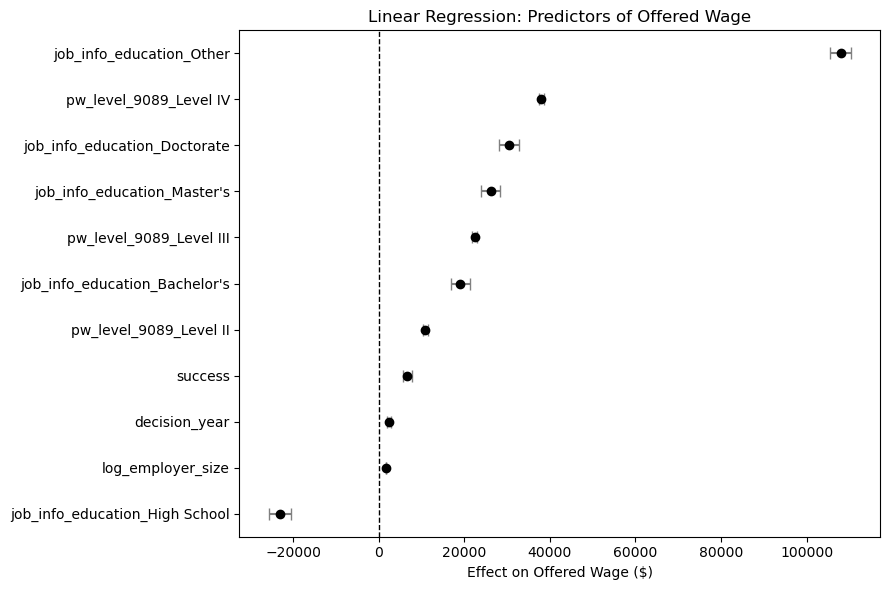

In [7]:
print(f"Rows after cleaning: {len(df)}")
df.head()
X = pd.get_dummies(
    df[['log_employer_size', 'pw_level_9089', 'job_info_education', 'decision_year', 'success']],
    columns=['pw_level_9089', 'job_info_education'],
    drop_first=True  # categories of education
)
X = X.astype(float)
X = sm.add_constant(X)

y = df['wage']  # outcome/offered wage in dollars

print(X.shape, y.shape)

model = sm.OLS(y, X).fit()
print(model.summary())

coefs = model.params.drop('const')
conf = model.conf_int().drop('const')
conf.columns = ['ci_low', 'ci_high']

coef_df = pd.DataFrame({'coef': coefs, 'ci_low': conf['ci_low'], 'ci_high': conf['ci_high']})
coef_df = coef_df.sort_values('coef')

plt.figure(figsize=(9, 6))
y_pos = np.arange(len(coef_df))
plt.errorbar(
    coef_df['coef'], y_pos,
    xerr=[coef_df['coef'] - coef_df['ci_low'], coef_df['ci_high'] - coef_df['coef']],
    fmt='o', color='black', ecolor='gray', capsize=4
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.yticks(y_pos, coef_df.index)
plt.xlabel("Effect on Offered Wage ($)")
plt.title("Linear Regression: Predictors of Offered Wage")
plt.tight_layout()
plt.show()